## Data Analysis

##### Import libraries

In [3]:
import os
import pandas as pd
from pathlib import Path
import inspect_ai.analysis as inspect
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
import numpy as np

##### Customize Plots

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from cycler import cycler

# --- Seaborn scientific theme ---
sns.set_theme(
    style="whitegrid",     # clean grid
    context="paper",       # compact for publications
    font_scale=1.1
)

# --- Matplotlib fine control ---
plt.rcParams.update({

    # Figure
    "figure.figsize": (6, 4),
    "figure.dpi": 150,
    "savefig.dpi": 300,

    # Fonts
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,

    # Lines
    "lines.linewidth": 1.8,
    "lines.markersize": 6,

    # Axes
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "gray",

    # Grid
    "grid.alpha": 0.4,
    "grid.linestyle": "--",

    # Legend
    "legend.frameon": False,
})

# TODO: Depending on the number of ciphers on which we end up running the algorithms, adjust the color palette. Useful: https://www.simplifiedsciencepublishing.com/resources/best-color-palettes-for-scientific-figures-and-data-visualizations
plt.rcParams['axes.prop_cycle'] = cycler(color=[
    "#082a54",
    "#2066a8",  
    "#8ec1da",
    # "#cde1ec",
    "#ededed",
    "#f6d6c2",
    "#d47264",
    "#ae282c",
])

### Import Data

In [5]:
log_dir = Path("final_logs")
eval_files = sorted(log_dir.glob("*.eval"))
dfs = []
for eval_path in eval_files:
    # do not include PRESENT 4 rounds with original prompt
    if eval_path.name == "PRESENT_4r_1.eval":
        continue
    temp = inspect.samples_df(
        eval_path,
        columns=[
            inspect.SampleColumn("sample_id", path="id", required=True, type=int),
            inspect.SampleColumn("cipher", path="metadata.algorithm", type=str),
            # inspect.SampleColumn("attack", path="metadata.attack", type=str),
            inspect.SampleColumn("rounds", path="metadata.rounds", type=int),
            inspect.SampleColumn(
                "queries",
                path="metadata.oracle_qc",
                value=lambda v: v[0] if isinstance(v, (list, tuple)) and len(v) > 0 else None,
                type=int,
            ),
            inspect.SampleColumn("working time", path="working_time", type=float),
            inspect.SampleColumn(
                "success",
                path="scores.scorer.value",
                value=lambda v: float(v) if pd.notna(v) else 0.0,
                type=float,
            ),
        ],
    )
    temp["source_eval"] = eval_path.name
    temp = temp.drop(columns=["log", "eval_id"])
    dfs.append(temp)

df_raw = pd.concat(dfs, ignore_index=True, sort=False)
df_raw["success"] = pd.to_numeric(df_raw["success"], errors="coerce").fillna(0.0)

Switch from `pyarrow` datatypes to standard python types

In [6]:
df_raw["queries"] = pd.to_numeric(df_raw["queries"], errors="coerce").astype("Int64")
df_raw = df_raw.astype(
    {
        "sample_id": "int64",
        "cipher": "string[python]",
        # "attack": "string[python]",
        "rounds": "int64",
        "queries": "int64",   # has missing values, so keep float or use Int64
        "working time": "float64",
        "success": "float64",
        "source_eval": "string[python]",
    }
)

In [7]:
df_raw.head()

,sample_id,cipher,rounds,queries,working time,success,source_eval
0,3,AES,1,20,442.319,1.0,AES_1r_1.eval
1,2,AES,1,4,469.935,1.0,AES_1r_1.eval
2,1,AES,1,8,478.109,1.0,AES_1r_1.eval
3,4,AES,1,8,724.405,1.0,AES_1r_1.eval
4,5,AES,1,40,861.923,1.0,AES_1r_1.eval


### Sample Corrections
#### Harness-Caused Corrections
On some occasions, either the 'InspectAI' framework bugged, or there were controller issues on our side. Due to this, small but truthful corrections were made in the data. They are described here in detail. See the `README.md` of this section to understan dhte naming convention of the samples that is being used.
1. The first run `PRESENT_1r_1.eval` had 15 instances. We realized that this was too expensive to keep for the entire benchmark so subsequent runs only contain 10 instances per level. Thus, to keep the data homogeneous throughout the analysis, we randomly drop 5 of these 15 instances.

In [8]:
target_indices = df_raw[(df_raw["cipher"] == "PRESENT") & (df_raw["rounds"] == 1)].index # get indeces of the desired samples
drop_indices = target_indices.to_series().sample(n=5, random_state=42).index # pick 5 indices to drop (w a seed for reproducibility)
df_raw = df_raw.drop(drop_indices) # drop them

2. `DES_3r_1_8.eval` never got access to the model. It can be seen because there are no input nor output tokens in the metadata. Because of this, a single other instance of DES 3 rounds was run (`DES_3r_2_1.eval`) and it is this sample that we use in the data analysis.

In [9]:
i = df_raw[(df_raw["cipher"] == "DES") & (df_raw["rounds"] == 3) & (df_raw["sample_id"] == 8)].index  # get the index of this unique sample
df_raw = df_raw.drop(i)  # then drop it
df_raw.loc[df_raw["source_eval"] == "DES_3r_2.eval", "sample_id"] = 8 # and rename the added sample to have sample_id = 8

3. `DES_3r_1_9.eval` succeeded in the key-recovery, yet failed the final scoring phase due to output hallucination of the verification ciphertext. More specifically, when copy pasting the resulting verification ciphertext from the sandbox output into the file `submission.txt`, the model hallucinates with respect to the output and thus outputs an incorrect result.

In [10]:
i = df_raw[(df_raw["cipher"] == "DES") & (df_raw["rounds"] == 3) & (df_raw["sample_id"] == 9)].index  # get the index of this unique sample
df_raw.loc[i, "success"] = 1.0 # set as successful

4. `PRESENT_4r_2_5.eval` suffered from the same issue as the sample above.

In [11]:
i = df_raw[(df_raw["source_eval"] == "PRESENT_4r_2.eval") & (df_raw["sample_id"] == 5)].index
df_raw.loc[i, "success"] = 1.0 # set as successful

5. `PRESENT_4r_2_4.eval` successfully recovers the key. This can be seen from the output of the last python code run by the model before the verification step, where the output key matches the samples' secret_key metadata. However, execution of the remaining phase seems to stall after this step, which stopped the model from passing the verification phase.

In [12]:
i = df_raw[(df_raw["source_eval"] == "PRESENT_4r_2.eval") & (df_raw["sample_id"] == 4)].index
df_raw.loc[i, "success"] = 1.0 # set as successful

#### Sandbox Timeout Corrections

In certain of the reduced round instances, we suspected/feared that the model was fialing due to overly restrictive sandbox time limits, as explained in the paper of this thesis. Because of this, certain samples were rerun with no specific time limits, to test the feasibility of the attack, isolated from sandbox constraints.  For the samples that succeeded, we manually correct them here. The files containing the code that was run (which is simply copy pasted from the model output, with minor adaptations for oracle use outside of the InspectAI framework) can be found in the folder `tests` and each file follows the same instance naming convention used thoughout the entire benchmark, which is explained in the `README.md`of this directory.

1. `PRESENT_4r_2_1.eval` was being limited by the sandbox constraints, and when run independently it succeeded with 180s of computation time. We thus count this sample as a success, in an attempt to make up for overly restrictive sandbox time constraints.

In [13]:
i = df_raw[(df_raw["source_eval"] == "PRESENT_4r_2.eval") & (df_raw["sample_id"] == 1)].index
df_raw.loc[i, "success"] = 1.0 # set as successful

2. `PRESENT_4r_2_3.eval` was being limited by the sandbox constraints, and when run independently it succeeded with 130s of computation time. We thus count this sample as a success, in an attempt to make up for overly restrictive sandbox time constraints.

In [14]:
i = df_raw[(df_raw["source_eval"] == "PRESENT_4r_2.eval") & (df_raw["sample_id"] == 3)].index
df_raw.loc[i, "success"] = 1.0 # set as successful

In [15]:
df = df_raw
df = df.sort_values(
    by=["cipher", "rounds", "source_eval", "sample_id"]
).reset_index(drop=True)

### Tagging of Attack Strategy
We export this dataset into excel, and prompt ChatGPT Pro to read through each transcript and tag it with the corresponding attack families that were attempted thoughout the sample. This attribute is a list of strings, chosen from within the following possibilities:
- `linear` Anything that’s basically linear cryptanalysis / linear approximations: looking for linear relations/correlations between plaintext/ciphertext/key bits, using biases, building linear equations from approximations, piling up many samples to distinguish / recover subkey bits.
- `differential` Differential-style reasoning: tracking XOR differences through rounds, high-probability differentials, truncated differentials, boomerang/rectangle-like language, filtering pairs by expected difference patterns.
- `SAT-style` Encoding constraints and solve with SAT/SMT/ILP/MILP” (e.g., CNF clauses, bit-blasting, Z3/CryptoMiniSat/Glucose, letting the solver find the key/state).
- `algebraic` Setting up polynomial equations over GF(2) (or similar), Gröbner bases / XL / linearization, solving multivariate systems, using algebraic normal form (ANF), convert S-boxes to equations and solve.
- `MITM` (meet-in-the-middle) Explicitly splitting the cipher into two (or more) parts, computing forward/backward tables, matching an intermediate value, time–memory tradeoff.
- `brute force` Explicit enumeration/search over candidate keys (or key parts, states, nonces, seeds), even if pruned or only over a reduced space.


In [16]:
# Create csv for annotation
def export():
    df_export = df.copy()
    df_export["row_id"] = (
        df_export["cipher"].astype(str) + "|" +
        df_export["rounds"].astype(str) + "|" +
        df_export["source_eval"].astype(str) + "|" +
        df_export["sample_id"].astype(str)
    )

    # columns you want to see while tagging
    cols = ["row_id", "cipher", "rounds", "source_eval", "sample_id"]
    df_export = df_export[cols].copy()

    # annotation column (manual)
    df_export["attack_family"] = ""

    df_export.to_csv("manual_annotation.csv", index=False)
    
# export()

In [17]:
# Merge back
ann = pd.read_csv("manual_annotation_filled.csv", usecols=["row_id", "attack_family"])

df_with_id = df.copy()
df_with_id["row_id"] = (
    df_with_id["cipher"].astype(str) + "|" +
    df_with_id["rounds"].astype(str) + "|" +
    df_with_id["source_eval"].astype(str) + "|" +
    df_with_id["sample_id"].astype(str)
)

df = df_with_id.merge(ann, on="row_id", how="left").drop(columns=["row_id"])

In [18]:
df.head()
print(df.shape[0])

120


# Data Analysis

In [19]:
df[(df["cipher"]=="AES")&(df["rounds"]==2)]

,sample_id,cipher,rounds,queries,working time,success,source_eval,attack_family
10,1,AES,2,60008,1841.823,1.0,AES_2r_1.eval,"SAT-style, differential, brute force"
11,2,AES,2,8,2196.049,1.0,AES_2r_1.eval,"SAT-style, differential, MITM"
12,3,AES,2,20,2722.315,1.0,AES_2r_1.eval,"SAT-style, differential, MITM, brute force"
13,4,AES,2,12,2753.660,1.0,AES_2r_1.eval,"SAT-style, MITM, brute force"
14,5,AES,2,40,1255.776,1.0,AES_2r_1.eval,"MITM, differential, brute force"
15,1,AES,2,40,1265.570,1.0,AES_2r_2.eval,"differential, MITM, brute force"
16,3,AES,2,40,790.713,1.0,AES_2r_2.eval,"differential, MITM, brute force"
17,4,AES,2,80000,842.221,1.0,AES_2r_2.eval,"differential, brute force"


In [20]:
# Ensure that we have the right number of samples per round
stats = (
    df_raw
    .groupby(["cipher", "rounds"])["sample_id"]
    .agg("count")
    .reset_index()
)
stats.head(30)

,cipher,rounds,sample_id
0,AES,1,10
1,AES,2,8
2,AES,3,10
3,DES,1,10
4,DES,2,10
5,DES,3,10
6,DES,4,10
7,DES,5,10
8,PRESENT,1,10
9,PRESENT,2,10


### Attack Strategies Distribution

Make table that gathers the counts by attack families

In [21]:
# Parse comma-separated attack families into one row per family
attack_family_long = (
    df[["rounds", "attack_family"]]
    .dropna(subset=["attack_family"])
    .assign(
        attack_family=lambda d: d["attack_family"].astype(str).str.split(",")
    )
    .explode("attack_family")
    .assign(
        attack_family=lambda d: d["attack_family"].str.strip()
    )
    .loc[lambda d: d["attack_family"] != ""]
)

# 1) Overall appearance count table of each attack family
attack_family_counts = (
    attack_family_long["attack_family"]
    .value_counts()
    .rename_axis("attack_family")
    .reset_index(name="count")
)
display(attack_family_counts)

,attack_family,count
0,brute force,98
1,algebraic,67
2,linear,32
3,SAT-style,29
4,MITM,14
5,differential,7


#### Stacked Bar Chart with Brute Force

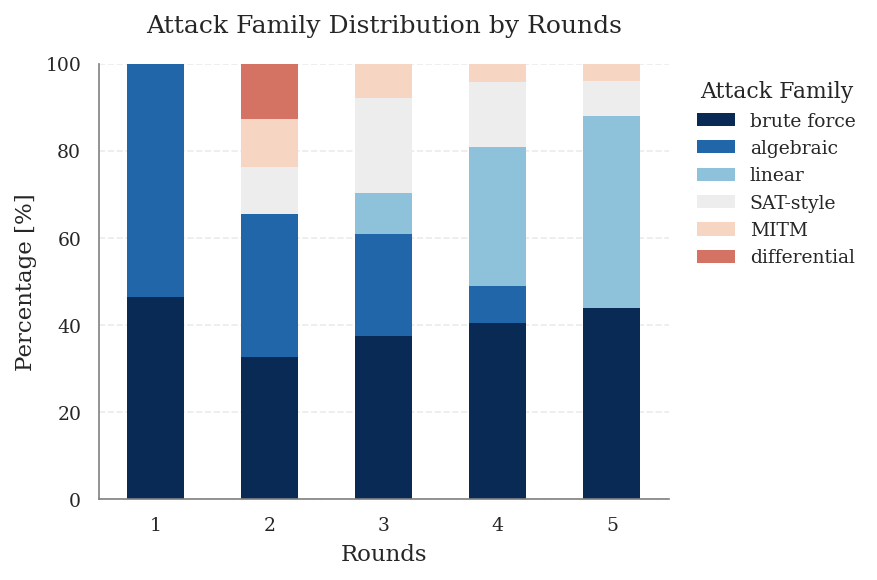

In [44]:
# Stacked percentage bar chart by rounds (independent of cipher)
round_family_counts = (
    attack_family_long
    .groupby(["rounds", "attack_family"])
    .size()
    .rename("count")
    .reset_index()
)

family_order = [
    "brute force",
    "algebraic",
    "linear",
    "SAT-style",
    "MITM",
    "differential",
    "others",
]

round_family_pct = (
    round_family_counts
    .assign(
        pct=lambda d: d["count"] / d.groupby("rounds")["count"].transform("sum") * 100
    )
    .pivot(index="rounds", columns="attack_family", values="pct")
    .fillna(0)
    .sort_index()
)

round_family_pct = round_family_pct.reindex(
    columns=[c for c in family_order if c in round_family_pct.columns],
    fill_value=0
)

ax = round_family_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(6, 4),
    edgecolor="none",
    linewidth=0,
)
ax.set_title("Attack Family Distribution by Rounds", pad=15)
ax.set_xlabel("Rounds")
ax.set_ylabel("Percentage [%]")
ax.tick_params(axis="x", labelrotation=0)
plt.setp(ax.get_xticklabels(), ha="center")
ax.legend(title="Attack Family", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../../../Bachelor-Thesis-Report/figures/attacks-rounds.pdf", bbox_inches="tight")
plt.show()

### Heatmap: Success Rate by Rounds and Cipher

In [24]:
# 2. Compute average success per cipher & round
pivot = (
    df
    .groupby(["cipher", "rounds"])["success"]
    .mean()
    .reset_index()
)

In [25]:
# 3. Make the table of success rate by cipher and rounds.
heatmap_df = pivot.pivot(
    index="cipher",   # rows
    columns="rounds", # columns
    values="success"  # cell values
)
heatmap_df = heatmap_df.sort_index(axis=1)
heatmap_df.head()

rounds,1,2,3,4,5
cipher,,,,,
AES,1.0,1.0,0.0,NaN,NaN
DES,1.0,1.0,0.9,0.8,0.2
PRESENT,1.0,1.0,1.0,0.8,0.0


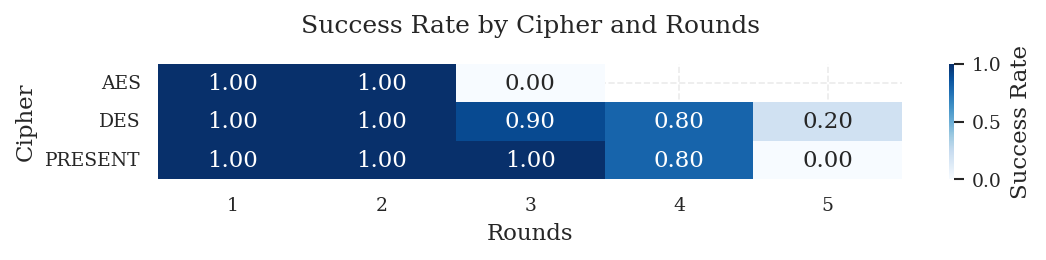

In [28]:
# 4. Make into a heatmap
plt.figure(figsize=(8, 1))

sns.heatmap(
    heatmap_df,
    annot=True,        # show numbers
    fmt=".2f",
    cmap="Blues",
    cbar_kws={"label": "Success Rate"},
)

plt.title("Success Rate by Cipher and Rounds", pad=15)
plt.xlabel("Rounds")
plt.ylabel("Cipher")
plt.savefig("../../../Bachelor-Thesis-Report/figures/heatmap.pdf", bbox_inches="tight")
plt.show()


#### Line Plot: Oracle Calls by Cipher and Rounds

In [29]:
# 1. In case that we run multiple attacks / goals, choose the specific ones we want for the graph
df_fixed = df[
    (df["success"] == 1.0)
]

In [30]:
# 2. Compute median, min and max oracles per cipher & round, only for the succesful samples
STATS = (
    df_fixed
    .groupby(["cipher", "rounds"])["queries"]
    .agg(q_min="min", q_med="median", q_max="max")
    .reset_index()
    .sort_values(["cipher", "rounds"])
)
STATS.head(20)

,cipher,rounds,q_min,q_med,q_max
0,AES,1,4,8.0,50
1,AES,2,8,40.0,80000
2,DES,1,8,20.0,64
3,DES,2,4,16.0,24
4,DES,3,8,32.0,200
5,DES,4,8,160000.0,250000
6,DES,5,200000,600000.0,1000000
7,PRESENT,1,8,20.0,50
8,PRESENT,2,8,40.0,200
9,PRESENT,3,10,30000.0,120000


In [31]:
def plot_queries():
    for cipher, sub in STATS.groupby("cipher"):
        x = sub["rounds"].to_numpy()
        y = sub["q_med"].to_numpy()

        yerr = np.vstack([
            y - sub["q_min"].to_numpy(),
            sub["q_max"].to_numpy() - y
        ])

        line, caplines, barlines = plt.errorbar(
            x, y,
            yerr=yerr,
            fmt="o-",
            capsize=4,
            elinewidth=1,
            markersize=5,
            label=cipher
        )

        # Make error bars transparent
        for bar in barlines:
            bar.set_alpha(0.5)

        for cap in caplines:
            cap.set_alpha(0.5)


    plt.xticks(np.arange(0, 7, 1)) # only tick at integers
    plt.title("Oracle Queries by Cipher and Rounds (median with min–max)")
    plt.xlabel("Rounds")
    plt.ylabel("Queries")
    plt.yscale("log")
    plt.legend(title="Cipher", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.savefig("../../Paper/figures/queries-rounds.pdf", bbox_inches="tight")
    plt.show()


### DES: Oracle Calls with Baseline

In [32]:
plt.rcParams['axes.prop_cycle'] = cycler(color=[
    "#082a54",
    "#2066a8",  
    "#8ec1da",
    "#d47264",
    "#ae282c",
])

In [33]:
# Oracle queries by round for a cipher: median, max, min, and baseline
def plot_cipher_queries(cipher, baseline, ax):
    stats = (
        STATS[STATS["cipher"] == cipher]
        .sort_values("rounds")
        .reset_index(drop=True)
    )

    if stats.empty:
        raise ValueError(f"No rows found in STATS for cipher '{cipher}'.")

    rounds = stats["rounds"].to_numpy()

    if len(baseline) != len(rounds):
        raise ValueError(
            f"Length mismatch: baseline has {len(baseline)} values but {cipher} has {len(rounds)} rounds."
        )

    q_max = pd.to_numeric(stats["q_max"], errors="coerce")
    q_med = pd.to_numeric(stats["q_med"], errors="coerce")
    q_min = pd.to_numeric(stats["q_min"], errors="coerce")
    baseline_series = pd.Series(baseline, dtype="float64")

    ax.plot(rounds, q_max, marker="o", label="Maximum")
    ax.plot(rounds, q_med, marker="o", label="Median")
    ax.plot(rounds, q_min, marker="o", label="Minimum")
    ax.plot(rounds, baseline_series, marker="o", linestyle="--", label="Human Baseline")

    ax.set_title(f"Oracle Queries of Successful {cipher} Attacks", pad=30, fontsize=12)
    ax.set_xlabel(f"Number of {cipher} Rounds")
    ax.set_ylabel("Oracle Queries [$\log_2$]")
    ax.set_xticks(rounds)

    # Use log scale only if all plotted values are strictly positive
    all_values = pd.concat([q_max, q_med, q_min, baseline_series], ignore_index=True).dropna()
    if (all_values > 0).all():
        ax.set_yscale("log", base=2)
    else:
        print(
            f"Warning: Non-positive query value(s) detected for {cipher}. Using linear y-scale instead of log."
        )

    ax.legend()

<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_55500/2483247270.py:31: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel("Oracle Queries [$\log_2$]")


In [34]:
# Heatmap: cipher-specific attack strategy usage percentage by round (excluding brute force)
def plot_cipher_strategies(cipher, ax):
    samples = df.loc[
        df["cipher"] == cipher,
        ["rounds", "sample_id", "source_eval", "attack_family", "success"],
    ].copy()

    if samples.empty:
        raise ValueError(f"No samples found for cipher '{cipher}'.")

    samples["sample_key"] = (
        samples["source_eval"].astype(str) + "|" + samples["sample_id"].astype(str)
    )

    total_samples_per_round = (
        samples.groupby("rounds")["sample_key"]
        .nunique()
        .rename("n_samples")
    )

    attack_mentions = (
        samples
        .dropna(subset=["attack_family"])
.assign(attack_family=lambda d: d["attack_family"].astype(str).str.split(","))
        .explode("attack_family")
        .assign(attack_family=lambda d: d["attack_family"].str.strip())
        .assign(
            attack_family=lambda d: d["attack_family"].replace({
                "guess-and-determine": "others",
                "guess and determine": "others",
                "integral": "others",
            })
        )
        .loc[lambda d: (d["attack_family"] != "") & (d["attack_family"] != "brute force")]
        .drop_duplicates(subset=["rounds", "sample_key", "attack_family"])
)

    samples_with_family = (
        attack_mentions
        .groupby(["rounds", "attack_family"])["sample_key"]
        .nunique()
        .rename("n_samples_with_family")
        .reset_index()
    )

    heatmap_pct = (
        samples_with_family
        .merge(total_samples_per_round.reset_index(), on="rounds", how="left")
        .assign(pct=lambda d: d["n_samples_with_family"] / d["n_samples"])
        .pivot(index="attack_family", columns="rounds", values="pct")
        .fillna(0)
    )

    family_order = [
        "algebraic",
        "linear",
        "SAT-style",
        "MITM",
        "differential",
        "others",
    ]
    heatmap_pct = heatmap_pct.reindex(
        [f for f in family_order if f in heatmap_pct.index]
    ).sort_index(axis=1)

    rounds_sorted = list(heatmap_pct.columns)
    success_rate_round = (
        samples.groupby("rounds")["success"]
        .mean()
        .mul(100)
        .reindex(rounds_sorted)
    )

    fig = ax.figure
    parent_spec = ax.get_subplotspec()
    ax.remove()

    # Dedicated colorbar axis keeps columns aligned between top and bottom heatmaps.
    inner = parent_spec.subgridspec(
        2, 2,
        height_ratios=[5, 0.55],
        width_ratios=[30, 1],
        hspace=0.08,
        wspace=0.08,
    )
    ax_hm = fig.add_subplot(inner[0, 0])
    ax_sr = fig.add_subplot(inner[1, 0], sharex=ax_hm)
    ax_cbar = fig.add_subplot(inner[0, 1])
    ax_blank = fig.add_subplot(inner[1, 1])
    ax_blank.axis("off")

    sns.heatmap(
        heatmap_pct,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        cbar=True,
        cbar_ax=ax_cbar,
        cbar_kws={"label": "Proportion of Samples"},
        ax=ax_hm,
    )
    cbar = ax_hm.collections[0].colorbar
    cbar.ax.tick_params(labelsize=7)
    cbar.set_label("Strategy share", fontsize=10)

    ax_hm.set_title(f"Attack Strategies Attempted + Succes Rate Across {cipher} Rounds", pad=15, fontsize=12)
    ax_hm.set_ylabel("Attack Strategies Attempted")
    ax_hm.xaxis.set_label_position("top")
    ax_hm.set_xlabel(f"{cipher} Rounds", labelpad=8)
    ax_hm.tick_params(axis="x", top=True, bottom=False, labeltop=True, labelbottom=False, length=0)

    success_rate_df = pd.DataFrame([success_rate_round.to_numpy()], columns=rounds_sorted)
    sns.heatmap(
        success_rate_df,
        annot=np.array([[f"{v:.2f}" if pd.notna(v) else "n/a" for v in success_rate_round.to_numpy()/100]]),
        fmt="",
        cmap="Blues",
        vmin=0,
        vmax=100,
        cbar=False,
        ax=ax_sr,
    )
    ax_sr.set_ylim(1, 0)
    ax_sr.set_yticks([])
    ax_sr.set_ylabel("")
    ax_sr.tick_params(axis="x", top=False, bottom=False, labeltop=False, labelbottom=False, length=0)
    ax_sr.set_xlabel("Success rate", labelpad=8)

    x0, x1 = ax_hm.get_xlim()
    ax_sr.set_xlim(x0, x1)

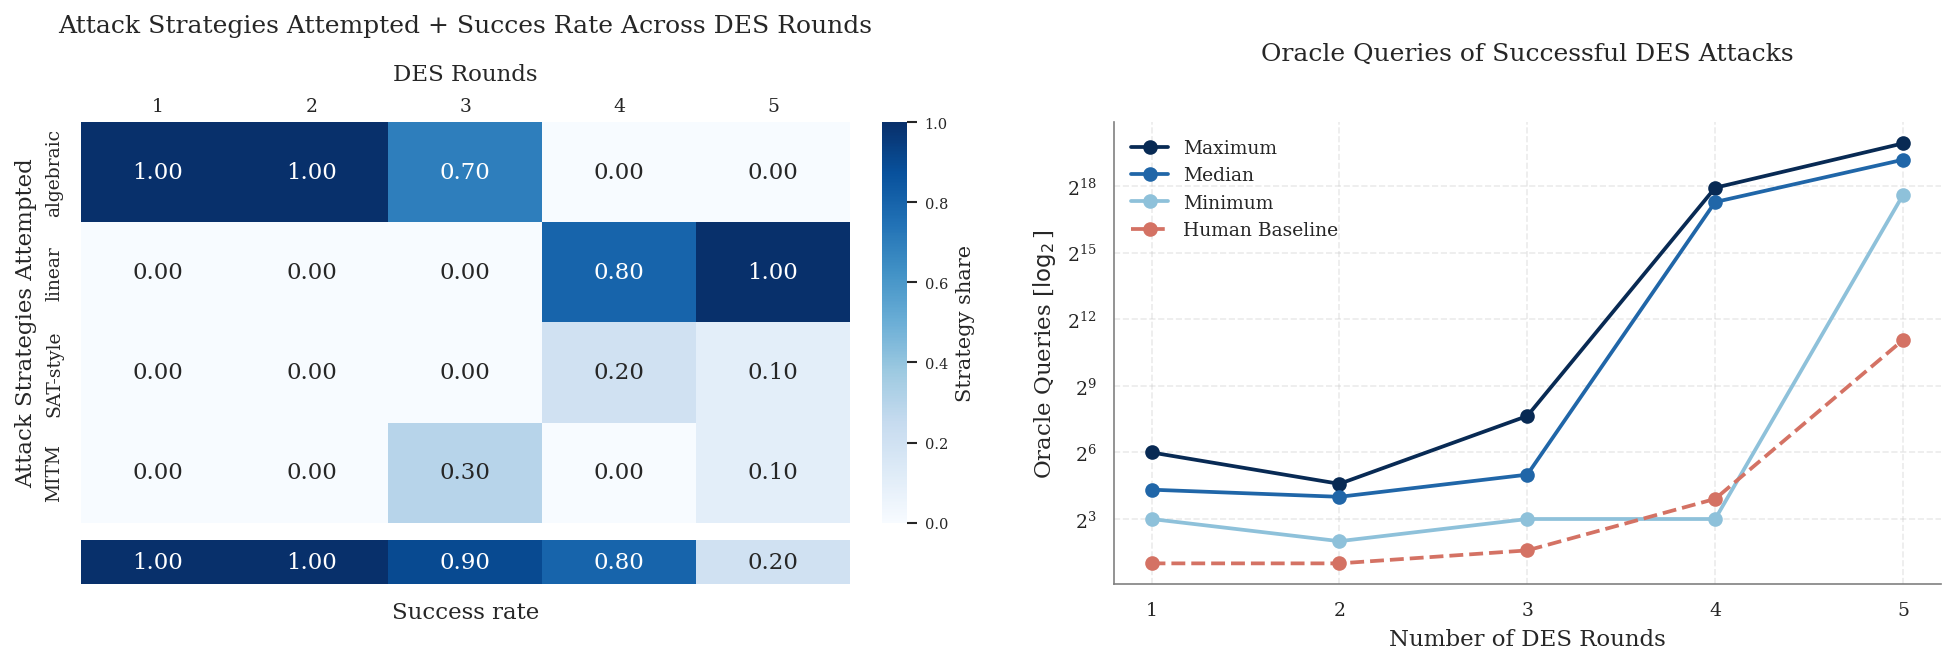

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={"wspace": 0.25})
plot_cipher_strategies("DES", axes[0])
plot_cipher_queries("DES", [2, 2, 3, 15, 2**11.07], axes[1])
plt.savefig("../../../Bachelor-Thesis-Report/figures/des-queries-and-strategies.pdf", bbox_inches="tight")
plt.show()

### PRESENT

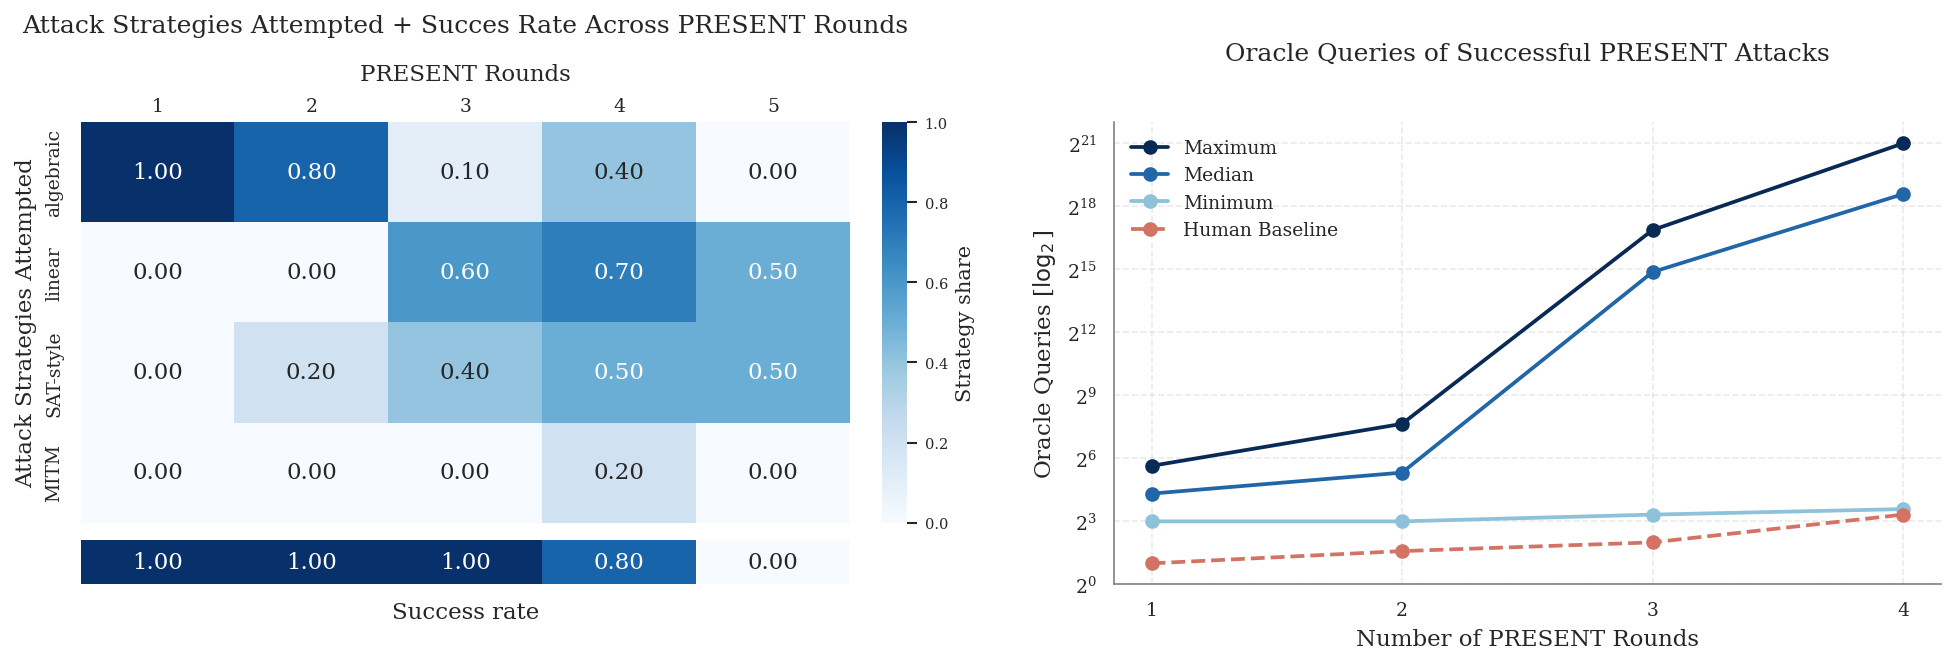

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={"wspace": 0.25})
plot_cipher_strategies("PRESENT", axes[0])
plot_cipher_queries("PRESENT", [2, 3, 4, 10], axes[1])
plt.savefig("../../../Bachelor-Thesis-Report/figures/present-queries-and-strategies.pdf", bbox_inches="tight")
plt.show()

### AES

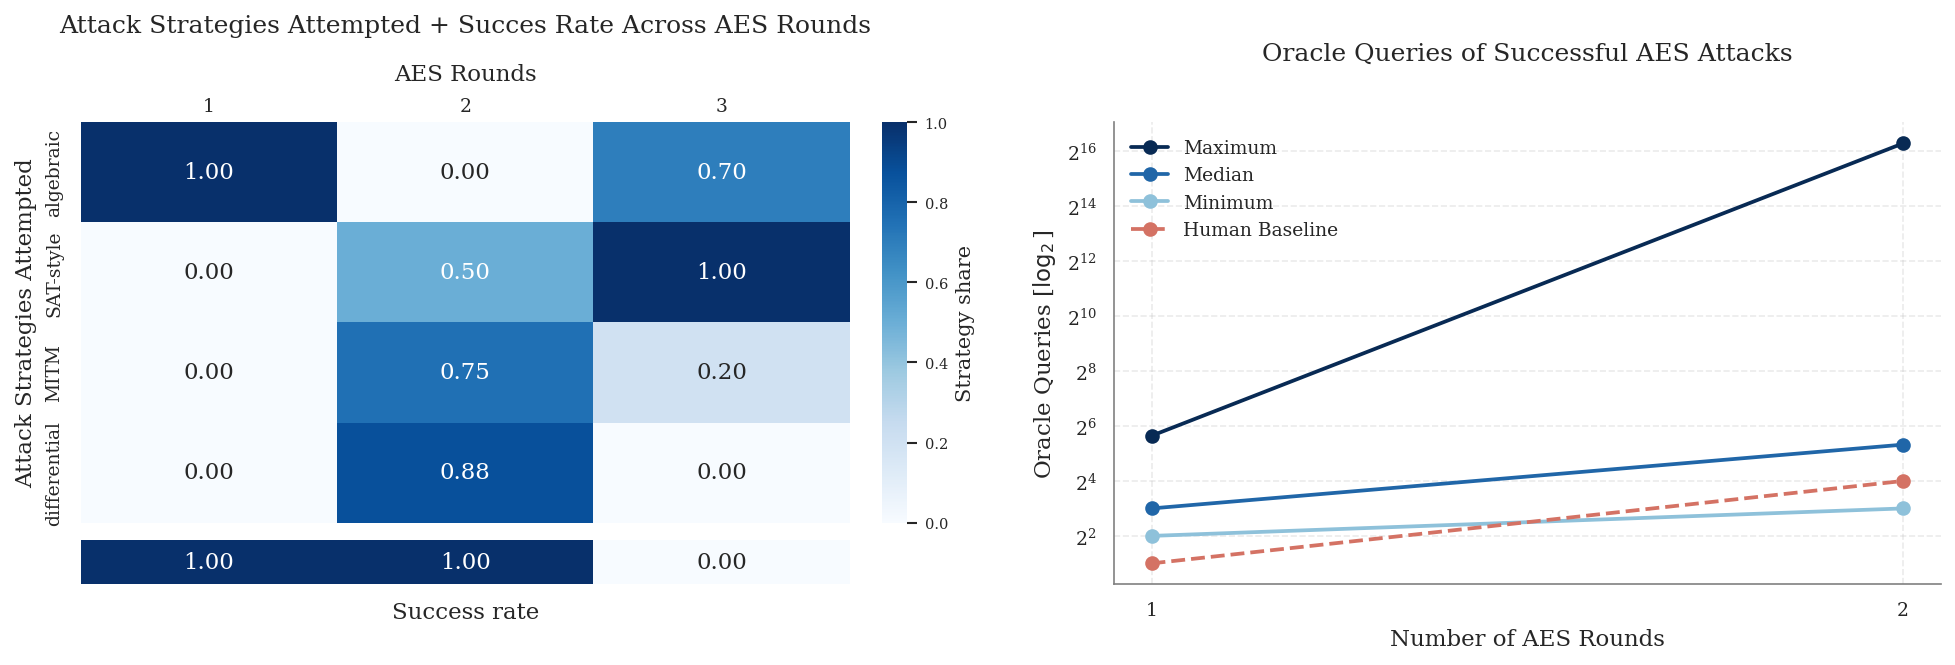

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={"wspace": 0.25})
plot_cipher_strategies("AES", axes[0])
plot_cipher_queries("AES", [2, 16], axes[1])
plt.savefig("../../../Bachelor-Thesis-Report/figures/aes-queries-and-strategies.pdf", bbox_inches="tight")
plt.show()